In [1]:
import xarray as xr
import pandas as pd
import numpy as np


ds_sat_diff = xr.open_dataset('LGMR_data/ds_sat_diff.nc')

ds_sat_diff.info()

xarray.Dataset {
dimensions:
	lat = 96 ;
	lon = 144 ;
	age = 119 ;

variables:
	float32 lat(lat) ;
		lat:FillValue = 9.969209968386869e+36 ;
		lat:long_name = vector latitudes ;
		lat:units = degrees_north ;
	float32 lon(lon) ;
		lon:FillValue = 9.969209968386869e+36 ;
		lon:long_name = vector of longitudes ;
		lon:units = degrees_east ;
	float32 age(age) ;
	float32 sat_diff(age, lat, lon) ;

// global attributes:
}

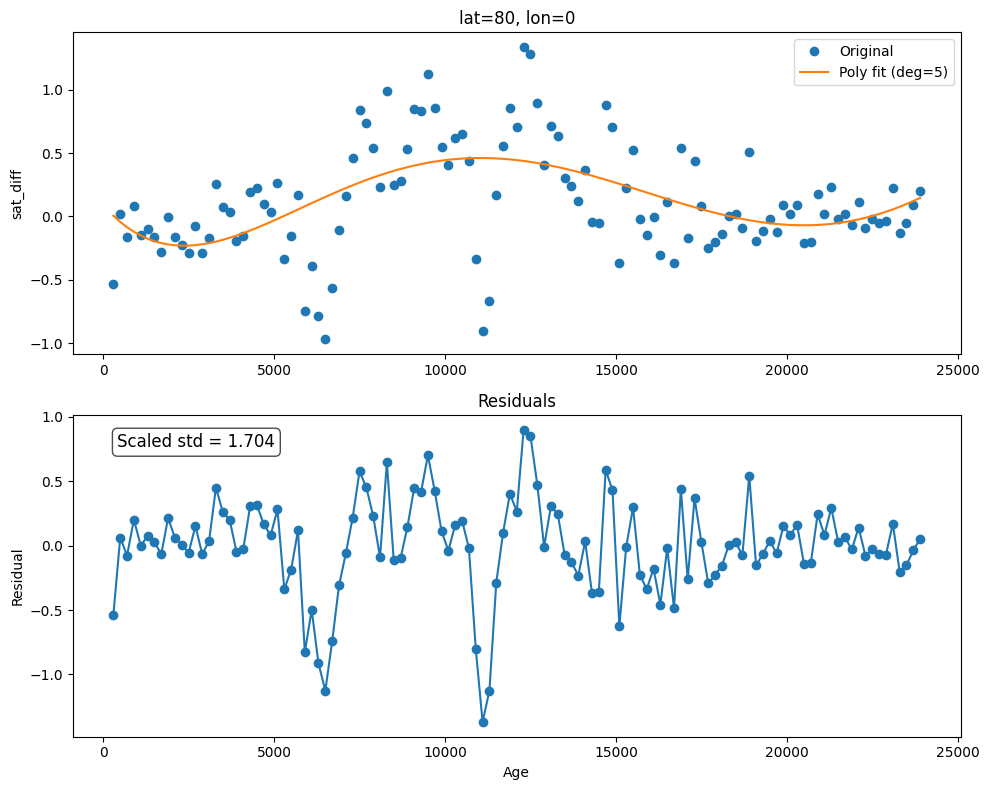

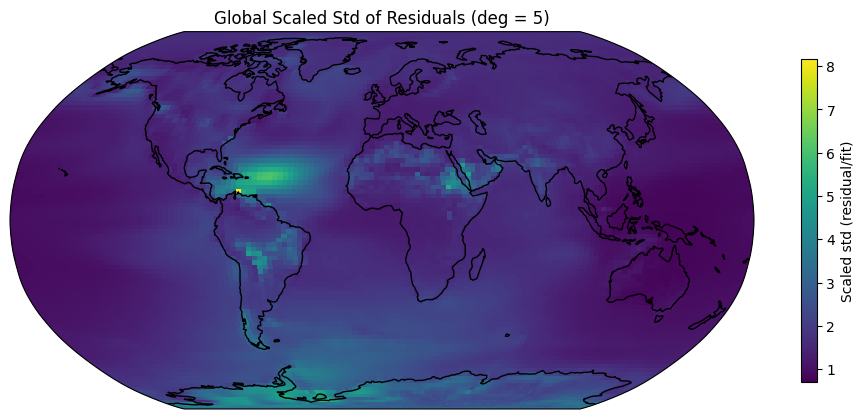

97.5% percentile 3.8534668207168576
2.5% percentile 0.8665147110819816
Median 1.6649028062820435


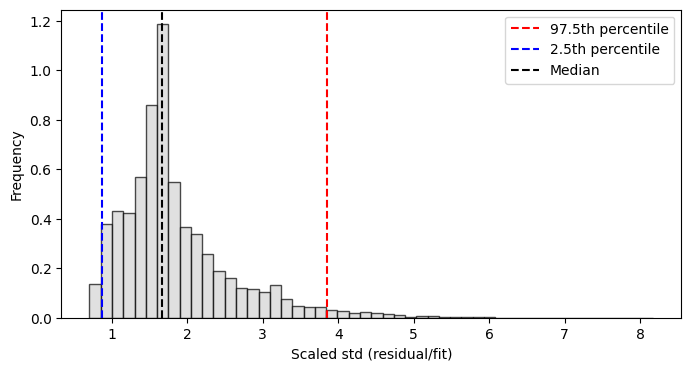

In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# 1) Load
ds       = xr.open_dataset('LGMR_data/ds_sat_diff.nc')
ages     = ds.age.values
lat_idx  = 80
lon_idx  = 0
y        = ds.sat_diff[:, lat_idx, lon_idx].values

# 2) Fit degree‑5 polynomial
deg      = 5
coeffs   = np.polyfit(ages, y, deg)
fitted   = np.polyval(coeffs, ages)
residual = y - fitted

# 3) Compute scaled std for this point
std_resid_pt = np.std(residual)
std_fit_pt   = np.std(fitted)
scaled_std_pt = std_resid_pt / std_fit_pt if std_fit_pt != 0 else np.nan

# 4) Plot original vs fitted & residuals + annotation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top: data & fit
ax1.plot(ages, y, 'o', label='Original')
ax1.plot(ages, fitted, '-', label=f'Poly fit (deg={deg})')
ax1.set_ylabel('sat_diff')
ax1.set_title(f'lat={lat_idx}, lon={lon_idx}')
ax1.legend()

# Bottom: residuals + scaled‐std text
ax2.plot(ages, residual, 'o-')
ax2.set_xlabel('Age')
ax2.set_ylabel('Residual')
ax2.set_title('Residuals')
# place box in upper‑left of axes
ax2.text(
    0.05, 0.90,
    f'Scaled std = {scaled_std_pt:.3f}',
    transform=ax2.transAxes,
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

plt.tight_layout()
plt.show()


# 5) Compute scaled‐std map
def compute_scaled_std(y_slice):
    c = np.polyfit(ages, y_slice, deg)
    fit = np.polyval(c, ages)
    resid = y_slice - fit
    s_res  = np.std(resid)
    s_fit  = np.std(fit)
    return s_res/s_fit if s_fit!=0 else np.nan

scaled_map = xr.apply_ufunc(
    compute_scaled_std,
    ds.sat_diff,
    input_core_dims=[['age']],
    vectorize=True,
    output_dtypes=[float]
)

# 6) Plot global map with smaller (shrunk) colorbar
fig = plt.figure(figsize=(12, 6))
ax  = plt.axes(projection=ccrs.Robinson())
scaled_map.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    cbar_kwargs={
        'label': 'Scaled std (residual/fit)',
        'shrink': 0.7      # shrink the colorbar to 70% of default
    }
)
ax.coastlines()
ax.set_global()
ax.set_title(f'Global Scaled Std of Residuals (deg = {deg})')
plt.show()


# plot the  histogram of scaled stds and show the 2.5th and 97.5th percentile
scaled_map.values.flatten()
# 7) Plot histogram of scaled stds
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    scaled_map.values.flatten(),
    bins=50,
    color='lightgray',
    edgecolor='black',
    alpha=0.7,
    density=True
)
ax.axvline(
    np.percentile(scaled_map.values.flatten(), 97.5),
    color='red',
    linestyle='--',
    label='97.5th percentile'
)
ax.axvline(
    np.percentile(scaled_map.values.flatten(), 2.5),
    color='blue',
    linestyle='--',
    label='2.5th percentile'
)
# plot median
ax.axvline(
    np.nanmedian(scaled_map.values.flatten()),
    color='black',
    linestyle='--',
    label='Median'
)
print('97.5% percentile',np.percentile(scaled_map.values.flatten(), 97.5))
print('2.5% percentile',np.percentile(scaled_map.values.flatten(), 2.5))
print('Median',np.nanmedian(scaled_map.values.flatten()))
ax.set_xlabel('Scaled std (residual/fit)')
ax.set_ylabel('Frequency')
ax.legend()
# ax.set_title('Histogram of Scaled Std of Residuals (degree=5)')


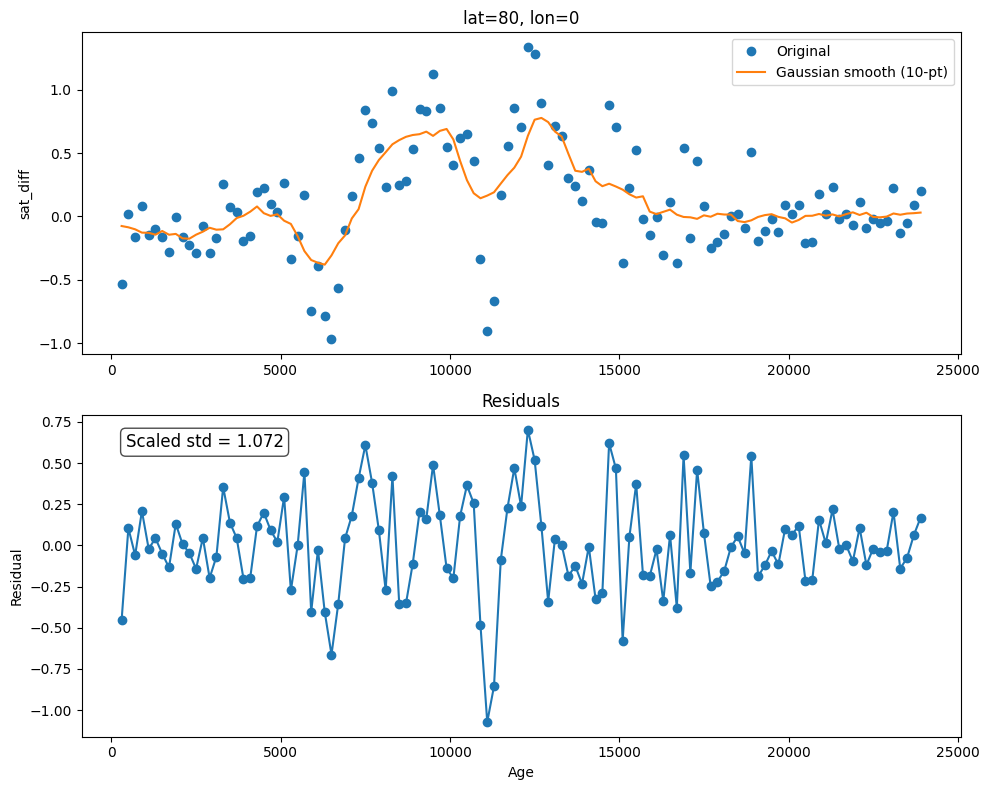

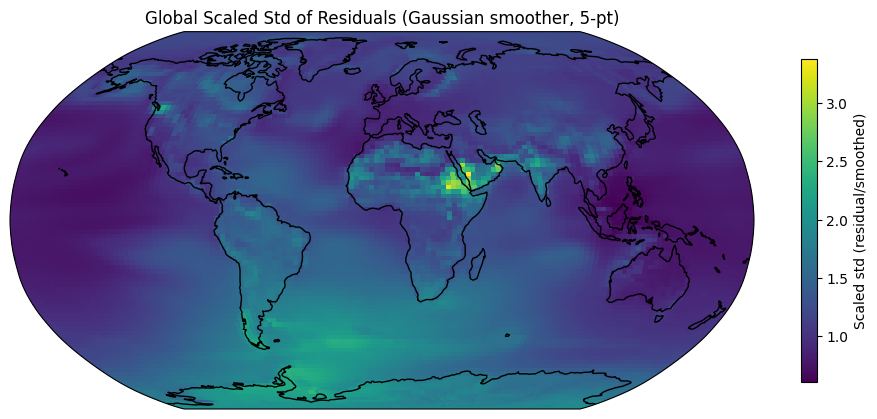

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# 1) Load data
ds       = xr.open_dataset('LGMR_data/ds_sat_diff.nc')
ages     = ds.age.values              # shape (119,)
lat_idx, lon_idx = 80, 0
y        = ds.sat_diff[:, lat_idx, lon_idx].values

# 2) Build a 5‑point Gaussian kernel (σ=1)
kernel_size = 10
sigma       = 10
# centered at zero:
x = np.arange(kernel_size) - (kernel_size//2)
kernel = np.exp(-0.5*(x/sigma)**2)
kernel /= kernel.sum()   # normalize to area=1

# 3) Smooth the single‐point time series
smooth_y = np.convolve(y, kernel, mode='same')
residual = y - smooth_y

# 4) Compute scaled std for this point
std_resid_pt  = np.std(residual)
std_smooth_pt = np.std(smooth_y)
scaled_std_pt = std_resid_pt / std_smooth_pt if std_smooth_pt!=0 else np.nan

# 5) Plot original vs smoothed & residuals + annotation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Top: data & smoothed curve
ax1.plot(ages, y, 'o', label='Original')
ax1.plot(ages, smooth_y, '-', label=f'Gaussian smooth ({kernel_size}‑pt)')
ax1.set_ylabel('sat_diff')
ax1.set_title(f'lat={lat_idx}, lon={lon_idx}')
ax1.legend()

# Bottom: residuals + scaled‑std text
ax2.plot(ages, residual, 'o-')
ax2.set_xlabel('Age')
ax2.set_ylabel('Residual')
ax2.set_title('Residuals')
ax2.text(
    0.05, 0.90,
    f'Scaled std = {scaled_std_pt:.3f}',
    transform=ax2.transAxes,
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
)

plt.tight_layout()
plt.show()

# 6) Now do it for every grid cell:
#    - apply the same convolution along age
arr = ds.sat_diff.values  # shape (age, lat, lon)

# Use np.apply_along_axis to smooth each (age,) series
smooth_arr = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode='same'),
                                 axis=0,
                                 arr=arr)

# Repack into an xarray DataArray
smooth_da = xr.DataArray(
    smooth_arr,
    coords=ds.sat_diff.coords,
    dims=ds.sat_diff.dims,
    name='smooth'
)

# Compute residual and per‑grid stds
residual_da     = ds.sat_diff - smooth_da
std_resid_map   = residual_da.std(dim='age')
std_smooth_map  = smooth_da.std(dim='age')
scaled_map      = std_resid_map / std_smooth_map

# 7) Plot the global map of scaled std
fig = plt.figure(figsize=(12, 6))
ax  = plt.axes(projection=ccrs.Robinson())
scaled_map.plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    cbar_kwargs={
        'label': 'Scaled std (residual/smoothed)',
        'shrink': 0.7
    }
)
ax.coastlines()
ax.set_global()
ax.set_title('Global Scaled Std of Residuals (Gaussian smoother, 5‑pt)')
plt.show()
